# Configurações Iniciais

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import numpy as np
import random
import torchvision.models as models
from tqdm import tqdm
import time
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo detetado: {device}")


Dispositivo detetado: cuda


# Definição da Arquitetura da Rede Neural

In [58]:
class ProjetoCNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super(ProjetoCNN, self).__init__()
        
        # Bloco 1: 32 filtros
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        # Bloco 2: 64 filtros
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        # Bloco 3: 128 filtros
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_conv = nn.Dropout(0.3)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))
        
        # Classificador
        self.fc1 = nn.Linear(128 * 2 * 2, 512)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Bloco 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout_conv(x)
        
        # Bloco 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.dropout_conv(x)

        # Bloco 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(x)
        x = self.dropout_conv(x)
        
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x


# Função de Avaliação

In [59]:
def avaliar_modelo(modelo, loader):
    modelo.eval()
    corretos = 0
    total = 0
    with torch.no_grad():
        for imagens, rotulos in loader:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            saidas = modelo(imagens)
            _, previstos = torch.max(saidas.data, 1)
            total += rotulos.size(0)
            corretos += (previstos == rotulos).sum().item()
    return 100 * corretos / total

# Treinamento e Avaliação no CIFAR-10

In [60]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

testset_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

classes_cifar = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

modelo_cifar = ProjetoCNN(in_channels=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_cifar = optim.Adam(modelo_cifar.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cifar, 'min', patience=3, factor=0.5)
scaler_cifar = GradScaler('cuda') if device.type == 'cuda' else None

epocas_cifar = 25
print(f"Iniciando treino CIFAR-10 ({epocas_cifar} épocas)...")

for epoch in range(epocas_cifar):
    modelo_cifar.train()
    running_loss = 0.0
    for imagens, rotulos in trainloader_cifar:
        imagens, rotulos = imagens.to(device, non_blocking=True), rotulos.to(device, non_blocking=True)
        optimizer_cifar.zero_grad(set_to_none=True)
        
        with autocast('cuda', enabled=(device.type == 'cuda')):
            saidas = modelo_cifar(imagens)
            loss = criterion(saidas, rotulos)
            
        if scaler_cifar:
            scaler_cifar.scale(loss).backward()
            scaler_cifar.step(optimizer_cifar)
            scaler_cifar.update()
        else:
            loss.backward()
            optimizer_cifar.step()
        
        running_loss += loss.item()
    
    custo_medio = running_loss/len(trainloader_cifar)
    scheduler.step(custo_medio)
    current_lr = optimizer_cifar.param_groups[0]['lr']
    print(f"Época {epoch+1}/{epocas_cifar} - Loss: {custo_medio:.4f} - LR: {current_lr}")

acuracia_cifar = avaliar_modelo(modelo_cifar, testloader_cifar)
print(f"Acurácia final no CIFAR-10: {acuracia_cifar:.2f}%")


/home/anselmo/projects/cnn/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Iniciando treino CIFAR-10 (25 épocas)...
Época 1/25 - Loss: 1.4534 - LR: 0.001
Época 2/25 - Loss: 1.1114 - LR: 0.001
Época 3/25 - Loss: 0.9773 - LR: 0.001
Época 4/25 - Loss: 0.8849 - LR: 0.001
Época 5/25 - Loss: 0.8243 - LR: 0.001
Época 6/25 - Loss: 0.7718 - LR: 0.001
Época 7/25 - Loss: 0.7334 - LR: 0.001
Época 8/25 - Loss: 0.7049 - LR: 0.001
Época 9/25 - Loss: 0.6751 - LR: 0.001
Época 10/25 - Loss: 0.6550 - LR: 0.001
Época 11/25 - Loss: 0.6349 - LR: 0.001
Época 12/25 - Loss: 0.6155 - LR: 0.001
Época 13/25 - Loss: 0.5988 - LR: 0.001
Época 14/25 - Loss: 0.5890 - LR: 0.001
Época 15/25 - Loss: 0.5728 - LR: 0.001
Época 16/25 - Loss: 0.5580 - LR: 0.001
Época 17/25 - Loss: 0.5514 - LR: 0.001
Época 18/25 - Loss: 0.5378 - LR: 0.001
Época 19/25 - Loss: 0.5273 - LR: 0.001
Época 20/25 - Loss: 0.5213 - LR: 0.001
Época 21/25 - Loss: 0.5179 - LR: 0.001
Época 22/25 - Loss: 0.5026 - LR: 0.001
Época 23/25 - Loss: 0.5029 - LR: 0.001
Época 24/25 - Loss: 0.4863 - LR: 0.001
Época 25/25 - Loss: 0.4870 - LR:

# Treinamento e Avaliação no MNIST

In [61]:
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
trainloader_mnist = torch.utils.data.DataLoader(trainset_mnist, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

testset_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)
testloader_mnist = torch.utils.data.DataLoader(testset_mnist, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

modelo_mnist = ProjetoCNN(in_channels=1).to(device)
optimizer_mnist = optim.Adam(modelo_mnist.parameters(), lr=0.001, weight_decay=1e-4)
scaler_mnist = GradScaler('cuda') if device.type == 'cuda' else None

print("Iniciando treino MNIST (5 épocas)...")
for epoch in range(5):
    modelo_mnist.train()
    running_loss = 0.0
    for imagens, rotulos in trainloader_mnist:
        imagens, rotulos = imagens.to(device, non_blocking=True), rotulos.to(device, non_blocking=True)
        optimizer_mnist.zero_grad(set_to_none=True)
        with autocast('cuda', enabled=(device.type == 'cuda')):
            saidas = modelo_mnist(imagens)
            loss = criterion(saidas, rotulos)
        if scaler_mnist:
            scaler_mnist.scale(loss).backward()
            scaler_mnist.step(optimizer_mnist)
            scaler_mnist.update()
        else:
            loss.backward()
            optimizer_mnist.step()
        running_loss += loss.item()
    print(f"Época {epoch+1} - Loss: {running_loss/len(trainloader_mnist):.4f}")

acuracia_mnist = avaliar_modelo(modelo_mnist, testloader_mnist)
print(f"Acurácia final no MNIST: {acuracia_mnist:.2f}%")


Iniciando treino MNIST (5 épocas)...
Época 1 - Loss: 0.2526
Época 2 - Loss: 0.0617
Época 3 - Loss: 0.0503
Época 4 - Loss: 0.0418
Época 5 - Loss: 0.0388
Acurácia final no MNIST: 99.28%


# Visualização das Ativações dos Kernels 

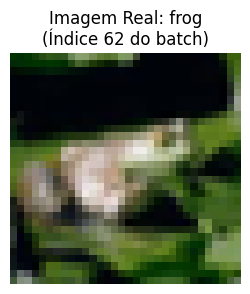

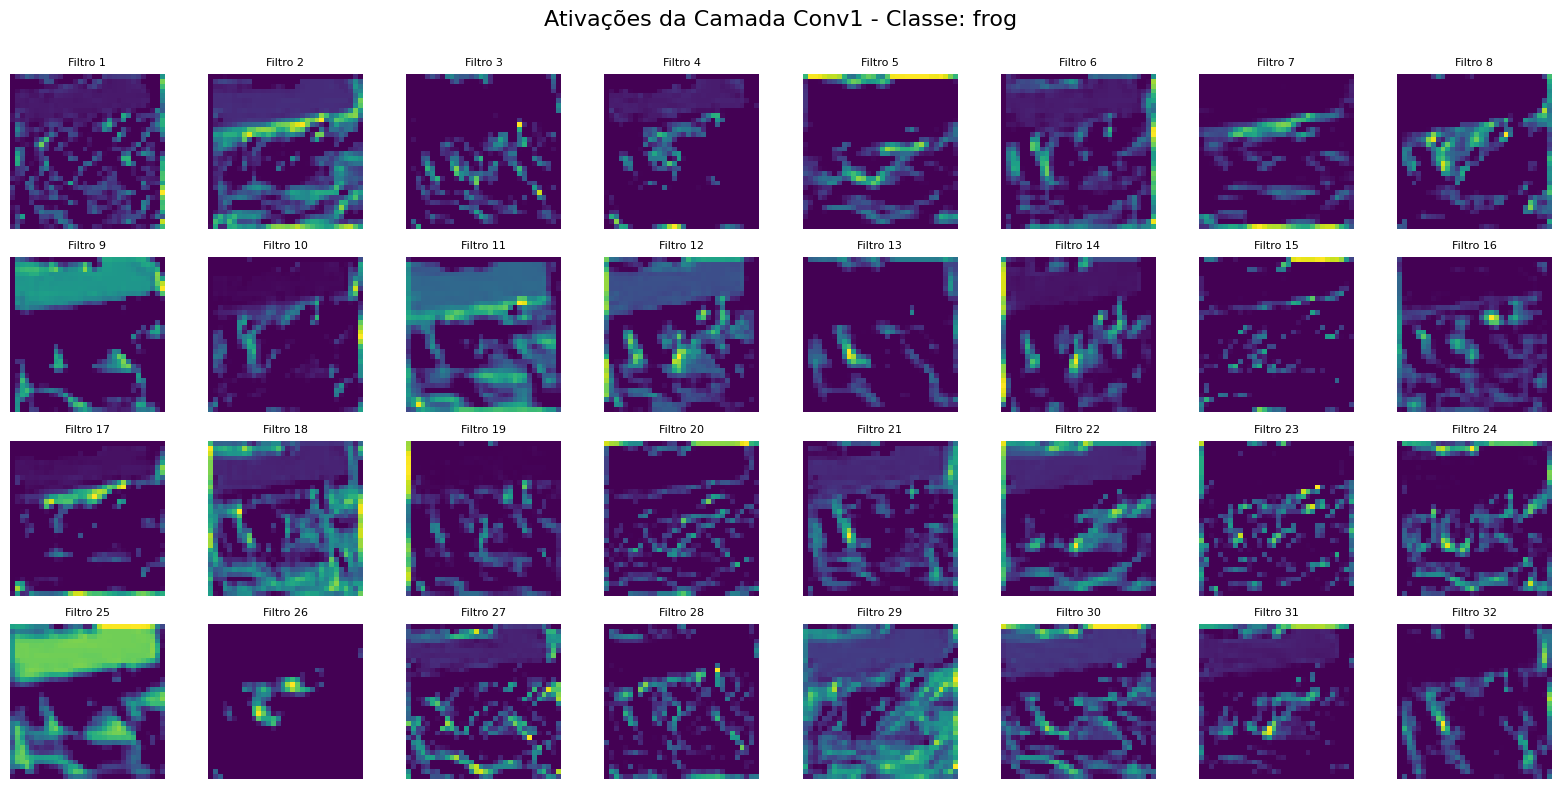

In [62]:
# 1. Pegar um lote de imagens e escolher uma aleatoriamente
dataiter = iter(testloader_cifar)
imagens, rotulos = next(dataiter)

# Seleciona um índice aleatório dentro do intervalo do lote
idx_aleatorio = random.randint(0, imagens.shape[0] - 1)

# Pegar a imagem sorteada e preparar para a rede
img_original = imagens[idx_aleatorio]
img_tensor = img_original.unsqueeze(0).to(device)
classe_real = classes_cifar[rotulos[idx_aleatorio]]

# 2. Extrair as ativações da PRIMEIRA camada convolucional
modelo_cifar.eval()
with torch.no_grad():
    ativacoes = F.relu(modelo_cifar.conv1(img_tensor))

# Removemos a dimensão do batch e jogamos para CPU
ativacoes = ativacoes.squeeze(0).cpu().numpy()

# 3. Plotar a imagem original para referência
img_display = img_original / 2 + 0.5 # Desnormaliza
npimg = img_display.numpy()
plt.figure(figsize=(3, 3))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.title(f'Imagem Real: {classe_real}\n(Índice {idx_aleatorio} do batch)')
plt.axis('off')
plt.show()

# 4. Plotar os 32 Feature Maps
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(f'Ativações da Camada Conv1 - Classe: {classe_real}', fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow(ativacoes[i], cmap='viridis') 
    ax.axis('off')
    ax.set_title(f'Filtro {i+1}', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


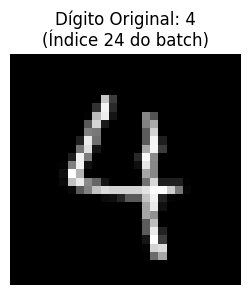

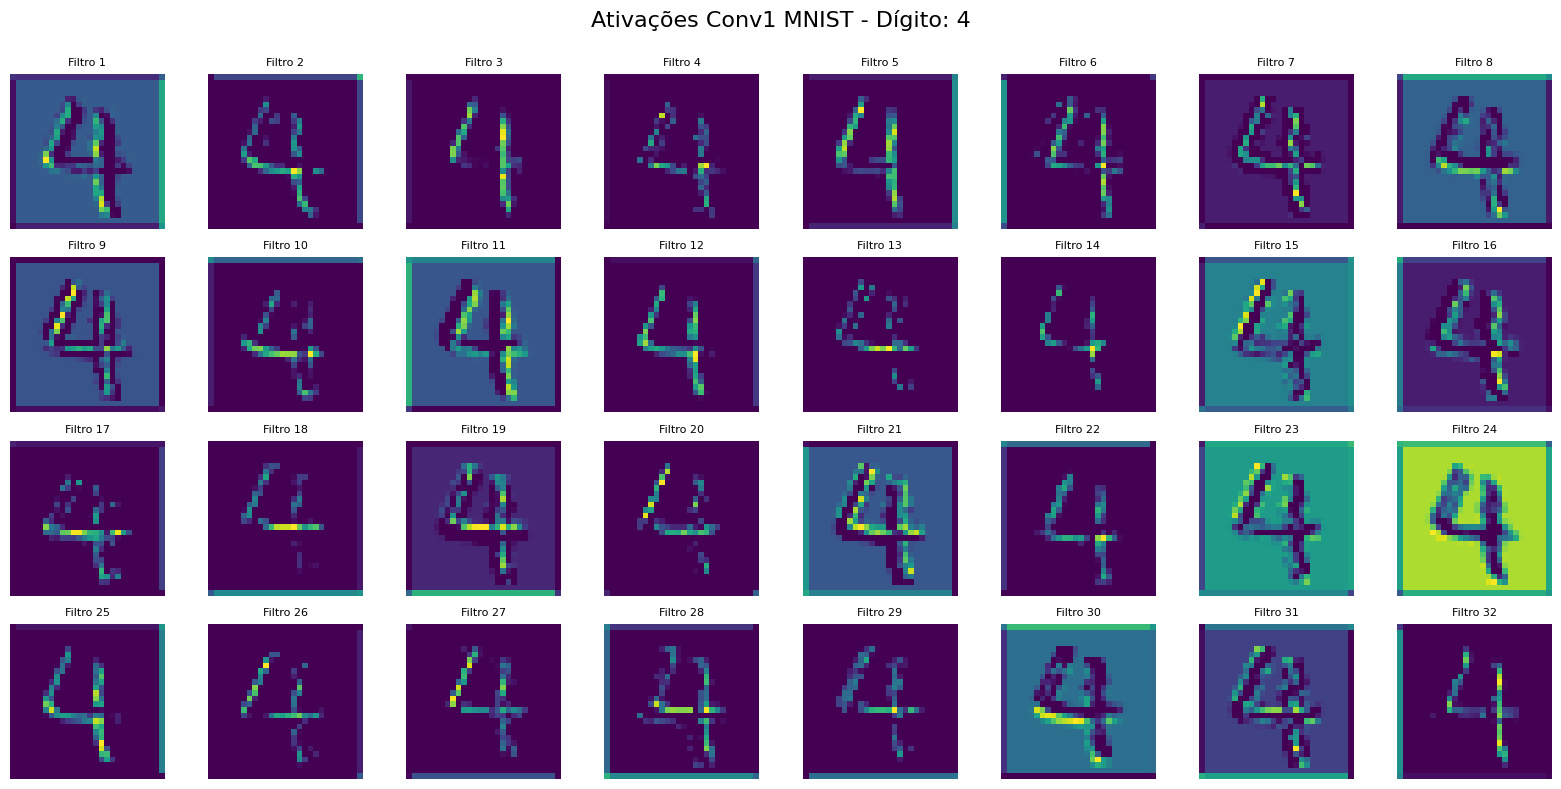

In [63]:
# 1. Preparação: Colocar o modelo em modo de avaliação
modelo_mnist.eval()

# 2. Pegar um lote de imagens do conjunto de testes
dataiter = iter(testloader_mnist)
imagens, rotulos = next(dataiter)

# Seleciona um índice aleatório
idx_aleatorio = random.randint(0, imagens.shape[0] - 1)
img_original = imagens[idx_aleatorio]
label_real = rotulos[idx_aleatorio].item()

# Preparamos o tensor para a rede
img_tensor = img_original.unsqueeze(0).to(device)

# 3. EXTRAÇÃO DAS ATIVAÇÕES
with torch.no_grad():
    ativacoes = F.relu(modelo_mnist.conv1(img_tensor))

ativacoes = ativacoes.squeeze(0).cpu().numpy()

# --- PLOTAGEM DOS RESULTADOS ---

# 4. Plotar a imagem original para referência
img_display = img_original.cpu() * 0.5 + 0.5
img_np = img_display.squeeze(0).numpy()

plt.figure(figsize=(3, 3))
plt.imshow(img_np, cmap='gray') 
plt.title(f'Dígito Original: {label_real}\n(Índice {idx_aleatorio} do batch)')
plt.axis('off')
plt.show()

# 5. Plotar os 32 Feature Maps
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(f'Ativações Conv1 MNIST - Dígito: {label_real}', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < 32:
        ax.imshow(ativacoes[i], cmap='viridis')
        ax.set_title(f'Filtro {i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


# Comparação CIFAR-10 vs ResNet18

In [66]:
print("\n--- Comparação CIFAR-10: ResNet18 ---")

# 1. Carregar ResNet18 pré-treinada
resnet18_cifar = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Adaptar para imagens 32x32 (3 canais)
resnet18_cifar.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet18_cifar.maxpool = nn.Identity()

# Ajustar saída para 10 classes
num_ftrs = resnet18_cifar.fc.in_features
resnet18_cifar.fc = nn.Linear(num_ftrs, 10)
resnet18_cifar = resnet18_cifar.to(device)

# 3. Configurações
optimizer_res_cifar = optim.Adam(resnet18_cifar.parameters(), lr=0.0001)
scaler_res_cifar = GradScaler('cuda') if device.type == 'cuda' else None

# 4. Treino Rápido (5 épocas)
for epoch in range(5):
    resnet18_cifar.train()
    for imagens, rotulos in trainloader_cifar:
        imagens, rotulos = imagens.to(device), rotulos.to(device)
        optimizer_res_cifar.zero_grad(set_to_none=True)
        with autocast('cuda', enabled=(device.type == 'cuda')):
            loss = nn.CrossEntropyLoss()(resnet18_cifar(imagens), rotulos)
        if scaler_res_cifar:
            scaler_res_cifar.scale(loss).backward()
            scaler_res_cifar.step(optimizer_res_cifar)
            scaler_res_cifar.update()
        else:
            loss.backward()
            optimizer_res_cifar.step()

acuracia_res_cifar = avaliar_modelo(resnet18_cifar, testloader_cifar)
print(f"\n[CIFAR-10] Sua Rede: {acuracia_cifar:.2f}% | ResNet18: {acuracia_res_cifar:.2f}%")



--- Comparação CIFAR-10: ResNet18 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/anselmo/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%



[CIFAR-10] Sua Rede: 85.73% | ResNet18: 90.57%


# Comparação MNIST vs ResNet18

In [70]:
print(f"\n--- Comparação MNIST: ResNet18 ---")

# 1. Carregar ResNet18 pré-treinada
resnet18_mnist = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Congelar camadas pré-treinadas
for param in resnet18_mnist.parameters():
    param.requires_grad = False

# 3. Adaptar para 1 canal (MNIST) e 10 classes
resnet18_mnist.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet18_mnist.maxpool = nn.Identity()
num_ftrs = resnet18_mnist.fc.in_features
resnet18_mnist.fc = nn.Linear(num_ftrs, 10)

resnet18_mnist = resnet18_mnist.to(device)

# 4. Usar um Learning Rate muito menor para evitar NaN
optimizer_res_mnist = optim.Adam(filter(lambda p: p.requires_grad, resnet18_mnist.parameters()), lr=0.0001)

# 5. Treino Curto
for epoch in range(2):
    resnet18_mnist.train()
    pbar = tqdm(trainloader_mnist, desc=f'Época {epoch+1}/2')
    for imagens, rotulos in pbar:
        imagens, rotulos = imagens.to(device), rotulos.to(device)
        optimizer_res_mnist.zero_grad()
        
        saidas = resnet18_mnist(imagens)
        loss = nn.CrossEntropyLoss()(saidas, rotulos)
        
        if torch.isnan(loss):
            continue # Pula se houver erro numérico
            
        loss.backward()
        optimizer_res_mnist.step()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

acuracia_res_mnist = avaliar_modelo(resnet18_mnist, testloader_mnist)
print(f"\n[MNIST] Sua Rede: {acuracia_mnist:.2f}% | ResNet18: {acuracia_res_mnist:.2f}%")



--- Comparação MNIST: ResNet18 ---


Época 2/2: 100%|██████████| 469/469 [02:21<00:00,  3.31it/s, loss=0.3599]



[MNIST] Sua Rede: 99.28% | ResNet18: 90.77%


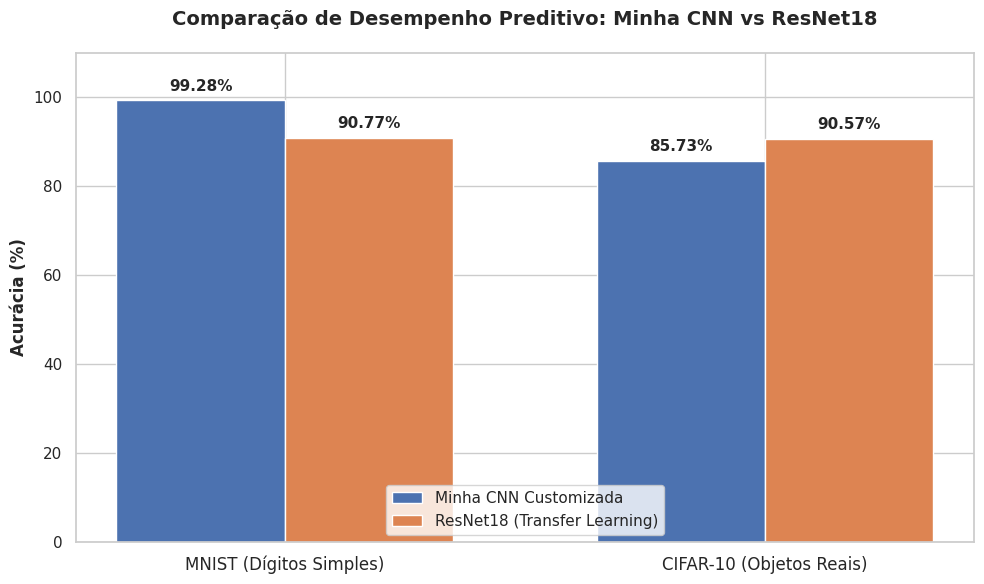

In [72]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

# Dados
datasets = ['MNIST (Dígitos Simples)', 'CIFAR-10 (Objetos Reais)']
acc_custom = [99.28, 85.73]
acc_resnet = [90.77, 90.57]

x = np.arange(len(datasets))  
width = 0.35  

# Criação do Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, acc_custom, width, label='Minha CNN Customizada', color='#4C72B0')
rects2 = ax.bar(x + width/2, acc_resnet, width, label='ResNet18 (Transfer Learning)', color='#DD8452')

# Formatação e Textos
ax.set_ylabel('Acurácia (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Desempenho Preditivo: Minha CNN vs ResNet18', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=12)
ax.legend(loc='lower center', fontsize=11)
ax.set_ylim(0, 110)

# Adicionar os valores no topo das barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()
